In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import math 
from math import exp

In [2]:
xdata_time = np.array([1, 2, 3, 4 , 5 ,6 , 7, 8 , 9, 10 ,11, 12])
#ydata_temp1 = np.array([30, 32, 36, 39, 41, 40, 38, 37, 38, 38, 35, 31])
ydata_temp = np.array([23.6, 25.8, 29.0, 32.8, 35, 34.8, 32.8, 31.2, 32.7, 33, 22.8, 25.0])
#ydata_temp2 = np.array([23.6, 25.8, 29, 32.8, 35, 34.8, 32.8, 31.2, 32.7, 33, 22.8, 25.0])
#zdata_rain1 = np.array([0, 0, 0.1, 0.5, 2.0, 6.3, 30.8, 37.9, 15.7, 4.2, 0.6, 0.1])
zdata_rain = np.array([0, 0, 0, 0, 5, 3, 25, 53, 24, 9, 0, 0])

In [3]:
from symfit import parameters, variables, sin, cos, Fit
import numpy as np
import matplotlib.pyplot as plt
np.product = np.prod

def fourier_series(x, f, n=0):
    """
    Returns a symbolic fourier series of order `n`.

    :param n: Order of the fourier series.
    :param x: Independent variable
    :param f: Frequency of the fourier series
    """
    # Make the parameter objects for all the terms
    a0, *cos_a = parameters(','.join(['a{}'.format(i) for i in range(0, n + 1)]))
    sin_b = parameters(','.join(['b{}'.format(i) for i in range(1, n + 1)]))
    # Construct the series
    series = a0 + sum(ai * cos((np.pi/6)*i * f * x) + bi * sin((np.pi/6)*i * f * x)
                     for i, (ai, bi) in enumerate(zip(cos_a, sin_b), start=1))
    return series

x, y = variables('x, y')
w, = parameters('w')
model_dict = {y: fourier_series(x, f=w, n=3)}
print(model_dict)

{y: a0 + a1*cos(0.523598775598299*w*x) + a2*cos(1.0471975511966*w*x) + a3*cos(1.5707963267949*w*x) + b1*sin(0.523598775598299*w*x) + b2*sin(1.0471975511966*w*x) + b3*sin(1.5707963267949*w*x)}



Parameter Value        Standard Deviation
a0        1.281255e+01 1.420339e+00
a1        1.415896e+01 4.489533e+00
a2        2.027517e+00 6.892494e+00
a3        -4.086560e+00 4.069989e+00
b1        -1.384187e+01 4.139632e+00
b2        -1.137459e+01 2.012882e+00
b3        -4.250847e+00 4.226830e+00
w         1.321329e+00 7.251604e-02
Status message         Desired error not necessarily achieved due to precision loss.
Number of iterations   202
Objective              <symfit.core.objectives.LeastSquares object at 0x00000228580DCD70>
Minimizer              <symfit.core.minimizers.BFGS object at 0x00000228580DCEC0>

Goodness of fit qualifiers:
chi_squared            80.12376385139015
objective_value        40.061881925695076
r_squared              0.9727925191370248


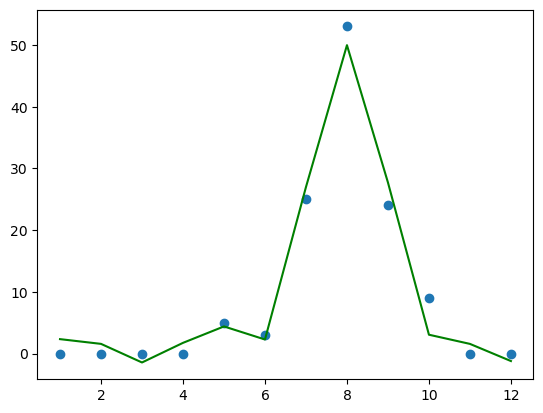

In [4]:
#Make step function data
#np.set_printoptions(precision = 4, suppress = True)
xdata = np.array([1,2,3,4,5,6,7,8,9,10,11,12])
#ydata = np.array([0.2372, 0.2814, 0.3433, 0.413, 0.4515, 0.4481, 0.413,  0.3841, 0.4112, 0.4165,0.2208, 0.2655])
ydata = zdata_rain
weight1 = np.pi/6*xdata
# Define a Fit object for this model and data
fit = Fit(model_dict, x= xdata, y=ydata)
fit_result = fit.execute()
print(fit_result)
# Plot the result
plt.plot(xdata, ydata, 'o')
plt.plot(xdata, fit.model(x=xdata, **fit_result.params).y, color='green', ls='-')